## A. IMAGINE
You are a engineer at a factory.
Your factory has jet engines running 24/7.
Each engine has 21 sensors stuck to it.
Every single day, those sensors send you a number.

<h1>Like this : </h1> 

Day 1:  Temperature = 518.67,  Pressure = 14.62,  Speed = 2388 ...

Day 2:  Temperature = 518.67,  Pressure = 14.62,  Speed = 2389 ...

Day 3:  Temperature = 518.68,  Pressure = 14.63,  Speed = 2391 ...

...
Day 192: ENGINE FAILS

NASA ran 100 engines until they all failed.
They recorded every sensor reading every day.
Then they gave us that data.
YOUR JOB: Look at the sensor readings and predict
→ "Is this engine going to fail within 30 days?" YES or NO.
That is literally it. Everything in this notebook is just steps toward answering that one question.

## 1. LOOK AT THE RAW DATA

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None)
print(df)

# sep='\s+' → the columns are separated by spaces
# (sep means separator — what separates each column)
# (\s+ means "one or more spaces")
# header=None → the file has NO column names in the first row
# (NASA just gave us numbers, no titles)
# df = ... → save the result into a variable called df
# (df stands for dataframe — just means "table")

        0    1       2       3      4       5       6        7        8   \
0        1    1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1        1    2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2        1    3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3        1    4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4        1    5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   
...    ...  ...     ...     ...    ...     ...     ...      ...      ...   
20626  100  196 -0.0004 -0.0003  100.0  518.67  643.49  1597.98  1428.63   
20627  100  197 -0.0016 -0.0005  100.0  518.67  643.54  1604.50  1433.58   
20628  100  198  0.0004  0.0000  100.0  518.67  643.42  1602.46  1428.18   
20629  100  199 -0.0011  0.0003  100.0  518.67  643.23  1605.26  1426.53   
20630  100  200 -0.0032 -0.0005  100.0  518.67  643.85  1600.38  1432.14   

          9   ...      16       17       18      19    20   21    22     23  \
0      1

## 3. How big is this data?

In OUTPUT

20631 means: 100 engines × roughly 200 days each = 20631 rows total. Each row = one engine on one day.

What 26 means:

Column 0 = which engine

Column 1 = which day
Columns 2,3,4 = operating settings (how the engine was being run)

Columns 5 to 25 = 21 sensor readings

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20631
Number of columns: 26


 ## 4. Look at just one engine

 Right now we have all 100 engines mixed together.
Let's look at just engine number 1.

In [4]:
# df[df['column'] == value] means "show me only rows where column equals value"
engine_1 = df[df[0] == 1]

print("Engine 1 data:")
print(engine_1)
print("Number of days engine 1 ran:", len(engine_1))

# What this does:
# df[0] → look at column number 0 (which is the engine ID column)
# == 1 → only where engine ID equals 1
# len(engine_1) → count how many rows (days) engine 1 has
# What you should see:
# All rows belonging to engine 1.
# The last number shows how many days engine 1 survived before failing.
# (Should be 192)

Engine 1 data:
     0    1       2       3      4       5       6        7        8      9   \
0     1    1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1     1    2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2     1    3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3     1    4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4     1    5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   
..   ..  ...     ...     ...    ...     ...     ...      ...      ...    ...   
187   1  188 -0.0067  0.0003  100.0  518.67  643.75  1602.38  1422.78  14.62   
188   1  189 -0.0006  0.0002  100.0  518.67  644.18  1596.17  1428.01  14.62   
189   1  190 -0.0027  0.0001  100.0  518.67  643.64  1599.22  1425.95  14.62   
190   1  191 -0.0000 -0.0004  100.0  518.67  643.34  1602.36  1425.77  14.62   
191   1  192  0.0009 -0.0000  100.0  518.67  643.54  1601.41  1427.20  14.62   

     ...      16       1

 ## 5. Give the columns proper names

 Right now columns are named 0, 1, 2, 3...
That's confusing. Let's give them real names.

In [5]:
# We make a list of names in the correct order
column_names = (
    ['engine_id', 'cycle'] +        # first 2 columns
    ['setting_1', 'setting_2', 'setting_3'] +  # next 3 columns
    ['sensor_' + str(i) for i in range(1, 22)]  # sensor_1 to sensor_21
)

# Assign these names to the dataframe
df.columns = column_names

# Show the result
print(df.head(5))

# What ['sensor_' + str(i) for i in range(1, 22)] means:
# This is called a list comprehension. It's a shortcut for:
# ['sensor_1', 'sensor_2', 'sensor_3', ..., 'sensor_21']

# Instead of typing all 21 names, we let Python generate them.
# range(1, 22) → numbers from 1 to 21 (range stops BEFORE the last number)
# str(i) → convert number to text so we can join it with 'sensor_'
# What you should see:
# Same data, but now columns say engine_id, cycle, setting_1, sensor_1 etc.
# Much easier to read!

   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

## 6. Look at one column

In [6]:
# Show just the engine_id column
print(df['engine_id'])

0          1
1          1
2          1
3          1
4          1
        ... 
20626    100
20627    100
20628    100
20629    100
20630    100
Name: engine_id, Length: 20631, dtype: int64


In [7]:
# How many unique engines are there?
print("Number of unique engines:", df['engine_id'].nunique())

Number of unique engines: 100


In [8]:
# What are the unique engine IDs?
print("Engine IDs:", df['engine_id'].unique())

# What we should see:
# Number of unique engines: 100
# Engine IDs: [1, 2, 3, 4, ... 100]
# So yes — exactly 100 engines. Each ran for a different number of days.

Engine IDs: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


## 7. How long did each engine survive?

What groupby does:
Imagine you have a list of exam scores for 30 students.
groupby('student_name') would group all scores by student.
Then .max() finds each student's highest score.
Here we group by engine and find the last cycle = how long it survived.
What you should see:
Each engine has a different survival number.
Some lived 128 cycles. Some lived 362 cycles.
This is real — different engines degrade at different rates.

In [9]:
# groupby = group all rows that belong to the same engine together
# then for each group, find the maximum cycle number
# max cycle = the last day the engine ran = when it failed

survival = df.groupby('engine_id')['cycle'].max()

print("How long each engine survived (in cycles/days):")
print(survival)
print()
print("Shortest lived engine:", survival.min(), "cycles")
print("Longest lived engine:", survival.max(), "cycles")
print("Average survival:", survival.mean().round(1), "cycles")

How long each engine survived (in cycles/days):
engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

Shortest lived engine: 128 cycles
Longest lived engine: 362 cycles
Average survival: 206.3 cycles


 ## 8. Look at sensor readings for one engine over time

 Let's actually SEE the data changing as an engine approaches failure.

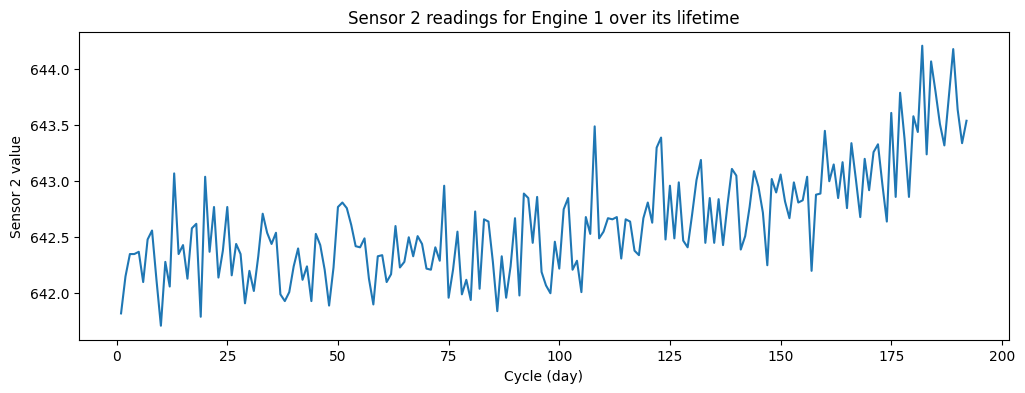

In [10]:
import matplotlib.pyplot as plt

# Get just engine 1's data
engine_1 = df[df['engine_id'] == 1].copy()

# Plot sensor_2 over time
plt.figure(figsize=(12, 4))
plt.plot(engine_1['cycle'], engine_1['sensor_2'])
plt.title('Sensor 2 readings for Engine 1 over its lifetime')
plt.xlabel('Cycle (day)')
plt.ylabel('Sensor 2 value')
plt.show()

# What you should see:
# A line graph. X axis = days. Y axis = sensor reading.
# The line should slowly drift upward or downward as the engine ages.
# That drift = the engine degrading.

## 9. Mark where the danger zone starts

The danger zone = last 30 cycles before failure.

Engine 1 survived: 192 cycles
Danger zone starts at cycle: 162


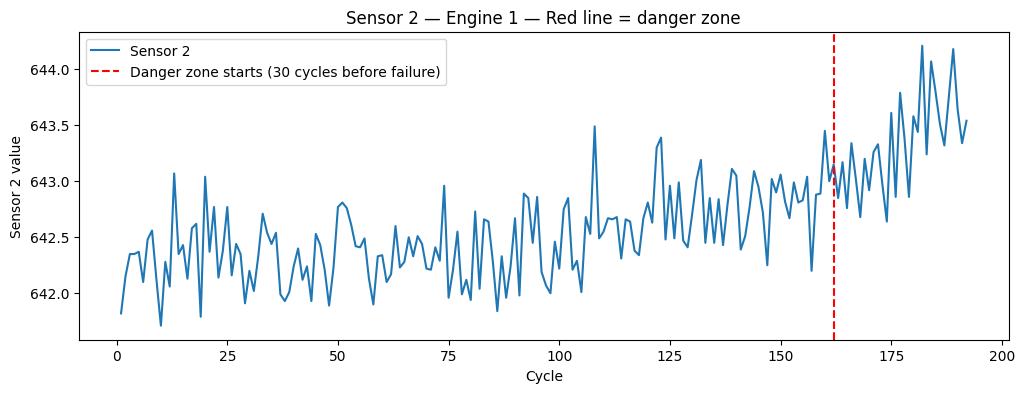

In [11]:
# How long did engine 1 survive?
engine_1_max_cycle = engine_1['cycle'].max()
print("Engine 1 survived:", engine_1_max_cycle, "cycles")
print("Danger zone starts at cycle:", engine_1_max_cycle - 30)

# Draw the same chart but with a red line marking the danger zone
plt.figure(figsize=(12, 4))
plt.plot(engine_1['cycle'], engine_1['sensor_2'], label='Sensor 2')

# Add a vertical red dashed line where danger zone starts
plt.axvline(
    x = engine_1_max_cycle - 30,
    color = 'red',
    linestyle = '--',
    label = 'Danger zone starts (30 cycles before failure)'
)

plt.title('Sensor 2 — Engine 1 — Red line = danger zone')
plt.xlabel('Cycle')
plt.ylabel('Sensor 2 value')
plt.legend()
plt.show()

## B. PART 2: CREATE THE LABELS

 ## 10. What is RUL?

RUL = Remaining Useful Life.
It means: "how many cycles does this engine have left?"
If an engine survived 192 cycles total:

At cycle 1   → RUL = 191 (191 days left)

At cycle 100 → RUL = 92  (92 days left)

At cycle 162 → RUL = 30  (30 days left — DANGER ZONE)

At cycle 192 → RUL = 0   (engine failed today)

In [12]:
# Step 1: Find the max cycle for each engine (already done above, let's redo it cleanly)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()

# reset_index() turns the result back into a normal table
# rename the column
max_cycles.columns = ['engine_id', 'max_cycle']

print("Max cycles per engine:")
print(max_cycles.head(10))

Max cycles per engine:
   engine_id  max_cycle
0          1        192
1          2        287
2          3        179
3          4        189
4          5        269
5          6        188
6          7        259
7          8        150
8          9        201
9         10        222


## 11. Attach max_cycle back to main dataframe

What merge does:

Before merge: df has engine_id and cycle

After merge: df also has max_cycle for each engine
Now every row knows the total lifespan of its engine.

In [13]:
# merge = join two tables together on a common column
# Like VLOOKUP in Excel
df = df.merge(max_cycles, on='engine_id')

print(df[['engine_id', 'cycle', 'max_cycle']].head(10))

   engine_id  cycle  max_cycle
0          1      1        192
1          1      2        192
2          1      3        192
3          1      4        192
4          1      5        192
5          1      6        192
6          1      7        192
7          1      8        192
8          1      9        192
9          1     10        192


## 12. Compute RUL

What you should see:
At cycle 1, RUL = 191
At cycle 2, RUL = 190
At cycle 3, RUL = 189
...counting down to 0 when the engine fails.

In [14]:
df['RUL'] = df['max_cycle'] - df['cycle']

print(df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(20))

    engine_id  cycle  max_cycle  RUL
0           1      1        192  191
1           1      2        192  190
2           1      3        192  189
3           1      4        192  188
4           1      5        192  187
5           1      6        192  186
6           1      7        192  185
7           1      8        192  184
8           1      9        192  183
9           1     10        192  182
10          1     11        192  181
11          1     12        192  180
12          1     13        192  179
13          1     14        192  178
14          1     15        192  177
15          1     16        192  176
16          1     17        192  175
17          1     18        192  174
18          1     19        192  173
19          1     20        192  172


 ## 13. Create the YES/NO label

We don't want to predict the exact RUL number.

We just want YES (engine will fail soon) or NO (engine is fine).

"Soon" = within 30 cycles.

In [15]:
# If RUL is 30 or less → label = 1 (DANGER — failure coming)
# If RUL is more than 30 → label = 0 (SAFE)

df['label'] = (df['RUL'] <= 30).astype(int)

print(df[['engine_id', 'cycle', 'RUL', 'label']].head(30))

#        What (df['RUL'] <= 30).astype(int) means step by step:
#        df['RUL'] <= 30 → for every row, check if RUL is 30 or less
#        -----> this gives True or False for every row
#        .astype(int) → convert True to 1, False to 0

# So:

# RUL = 191 → False → 0 (safe)
# RUL = 30  → True  → 1 (danger)
# RUL = 5   → True  → 1 (danger)

    engine_id  cycle  RUL  label
0           1      1  191      0
1           1      2  190      0
2           1      3  189      0
3           1      4  188      0
4           1      5  187      0
5           1      6  186      0
6           1      7  185      0
7           1      8  184      0
8           1      9  183      0
9           1     10  182      0
10          1     11  181      0
11          1     12  180      0
12          1     13  179      0
13          1     14  178      0
14          1     15  177      0
15          1     16  176      0
16          1     17  175      0
17          1     18  174      0
18          1     19  173      0
19          1     20  172      0
20          1     21  171      0
21          1     22  170      0
22          1     23  169      0
23          1     24  168      0
24          1     25  167      0
25          1     26  166      0
26          1     27  165      0
27          1     28  164      0
28          1     29  163      0
29        

## 14. How many safe vs danger rows do we have?

In [16]:
count = df['label'].value_counts()
print("Label counts:")
print(count)
print()
print("0 = safe rows:  ", count[0])
print("1 = danger rows:", count[1])
print()
total = len(df)
danger_percent = count[1] / total * 100
print(f"Only {danger_percent:.1f}% of rows are danger rows")
print("This means the data is imbalanced — more safe than danger")

# What you should see:
# Something like:
# 0 = 15,631 rows (safe)
# 1 = 5,000 rows (danger)
# Only ~24% are danger rows.
# Why this matters:
# If your model just always says "safe" for everything,
# it would be right 76% of the time — but completely useless!
# This is why accuracy alone is a bad metric.
# We'll use AUC-ROC instead (explained later).

Label counts:
label
0    17531
1     3100
Name: count, dtype: int64

0 = safe rows:   17531
1 = danger rows: 3100

Only 15.0% of rows are danger rows
This means the data is imbalanced — more safe than danger


## C. EXPLORE THE SENSORS
_________________________

Some sensors in this dataset never change. They're constant.
A constant sensor tells the model NOTHING.
We need to find and remove them.

In [17]:
sensor_columns = ['sensor_' + str(i) for i in range(1, 22)]

print("How many different values each sensor has:")
print()

for sensor in sensor_columns:
    unique_count = df[sensor].nunique()
    min_val = df[sensor].min()
    max_val = df[sensor].max()
    print(f"{sensor}: {unique_count} unique values  (min={min_val:.2f}, max={max_val:.2f})")

# What you should see:
# Some sensors have thousands of unique values — they change a lot — USEFUL
# Some sensors have only 1 or 2 unique values — they barely change — NOT USEFUL
    

How many different values each sensor has:

sensor_1: 1 unique values  (min=518.67, max=518.67)
sensor_2: 310 unique values  (min=641.21, max=644.53)
sensor_3: 3012 unique values  (min=1571.04, max=1616.91)
sensor_4: 4051 unique values  (min=1382.25, max=1441.49)
sensor_5: 1 unique values  (min=14.62, max=14.62)
sensor_6: 2 unique values  (min=21.60, max=21.61)
sensor_7: 513 unique values  (min=549.85, max=556.06)
sensor_8: 53 unique values  (min=2387.90, max=2388.56)
sensor_9: 6403 unique values  (min=9021.73, max=9244.59)
sensor_10: 1 unique values  (min=1.30, max=1.30)
sensor_11: 159 unique values  (min=46.85, max=48.53)
sensor_12: 427 unique values  (min=518.69, max=523.38)
sensor_13: 56 unique values  (min=2387.88, max=2388.56)
sensor_14: 6078 unique values  (min=8099.94, max=8293.72)
sensor_15: 1918 unique values  (min=8.32, max=8.58)
sensor_16: 1 unique values  (min=0.03, max=0.03)
sensor_17: 13 unique values  (min=388.00, max=400.00)
sensor_18: 1 unique values  (min=2388.00, ma

## 16. Remove the useless sensors

In [18]:
# Keep only sensors that have more than 2 unique values
useful_sensors = []

for sensor in sensor_columns:
    if df[sensor].nunique() > 2:
        useful_sensors.append(sensor)

dropped_sensors = [s for s in sensor_columns if s not in useful_sensors]

print("Sensors we KEEP:", useful_sensors)
print()
print("Sensors we DROP (constant or near-constant):", dropped_sensors)
print()
print("Total useful sensors:", len(useful_sensors))

# What you should see:
# You keep around 14 sensors.
# You drop around 7 sensors (sensors 1, 5, 6, 10, 16, 18, 19 are usually constant in FD001).

Sensors we KEEP: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Sensors we DROP (constant or near-constant): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Total useful sensors: 14


## 17. Plot useful sensors for one engine

Let's visually confirm our useful sensors actually change near failure.

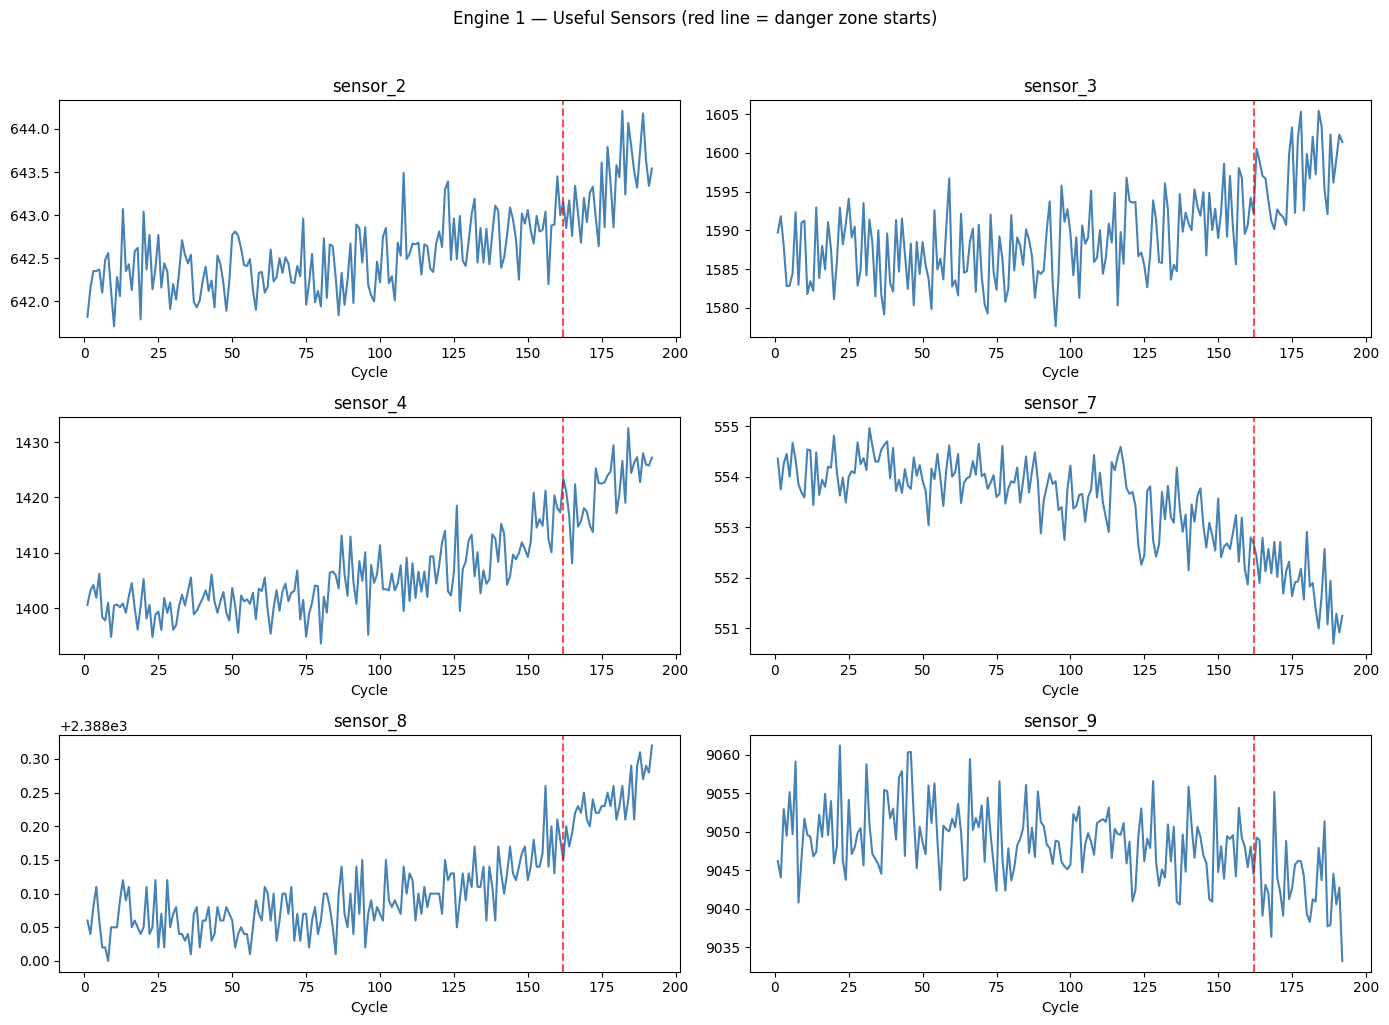

In [19]:
engine_1 = df[df['engine_id'] == 1].copy()
failure_cycle = engine_1['cycle'].max()
danger_start = failure_cycle - 30

# Plot first 6 useful sensors
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()  # make it a simple list instead of 2D grid

for i, sensor in enumerate(useful_sensors[:6]):
    axes[i].plot(engine_1['cycle'], engine_1[sensor], color='steelblue')
    axes[i].axvline(x=danger_start, color='red', linestyle='--', alpha=0.7)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.suptitle('Engine 1 — Useful Sensors (red line = danger zone starts)', y=1.02)
plt.tight_layout()
plt.show()

# What you should see:
# 6 small charts. Each one shows a sensor over time.
# The red dashed line is where the engine entered the danger zone.
# Some sensors will clearly change after the red line — those are the best predictors.

## 4. NORMALIZE THE DATA

 ## 18. Why we need to normalize
<body>
Right now:

sensor_3 has values around 1400 to 1650
sensor_15 has values around 8.3 to 8.5

These are VERY different scales.
If we feed this to a neural network as-is,
sensor_3 will dominate just because its numbers are bigger.
The model will barely pay attention to sensor_15.
Solution: scale everything to be between 0 and 1.
</body>

In [20]:
# First, let's see the problem clearly
print("BEFORE normalization:")
print()
for sensor in useful_sensors[:5]:
    print(f"{sensor}: min={df[sensor].min():.2f}, max={df[sensor].max():.2f}")

# What you should see:
# Wildly different ranges — some sensors in the thousands, some near zero.

BEFORE normalization:

sensor_2: min=641.21, max=644.53
sensor_3: min=1571.04, max=1616.91
sensor_4: min=1382.25, max=1441.49
sensor_7: min=549.85, max=556.06
sensor_8: min=2387.90, max=2388.56


 ## 19. Normalize using MinMaxScaler

In [21]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler converts everything to be between 0 and 1
# Formula it uses: (value - min) / (max - min)
# Example: if sensor_3 goes from 1400 to 1650:
#   value 1400 → (1400-1400)/(1650-1400) = 0/250 = 0.0
#   value 1525 → (1525-1400)/(1650-1400) = 125/250 = 0.5
#   value 1650 → (1650-1400)/(1650-1400) = 250/250 = 1.0

scaler = MinMaxScaler()

# fit_transform does two things:
# fit = learn the min and max of each sensor
# transform = apply the formula to scale all values
df[useful_sensors] = scaler.fit_transform(df[useful_sensors])

print("AFTER normalization:")
print()
for sensor in useful_sensors[:5]:
    print(f"{sensor}: min={df[sensor].min():.2f}, max={df[sensor].max():.2f}")

# What you should see:
# AFTER normalization, every sensor goes from 0.00 to 1.00.
# All sensors now on equal footing.

AFTER normalization:

sensor_2: min=0.00, max=1.00
sensor_3: min=0.00, max=1.00
sensor_4: min=0.00, max=1.00
sensor_7: min=0.00, max=1.00
sensor_8: min=0.00, max=1.00


## D. CREATE TRAINING WINDOWS
__________________________
(Turn the table into chunks the neural network can eat)

## 20. What is a sliding window?

<body>
    A neural network doesn't look at one row at a time.
It looks at a SEQUENCE of rows — 30 rows at a time.
Why? Because one day's sensor reading tells you almost nothing.
But 30 days of readings TOGETHER show you the trend.
Is the temperature slowly rising? Is the pressure dropping?
The TREND is what predicts failure. Not a single snapshot.


Example for Engine 1 (survived 192 cycles):

<p>Window 1:  cycles 1-30   → label = 0 (still 162 cycles left, safe)<br>
Window 2:  cycles 2-31   → label = 0 (still 161 cycles left, safe)<br>
Window 3:  cycles 3-32   → label = 0 (still 160 cycles left, safe)<br>
...<br>
Window 163: cycles 163-192 → label = 1 (0 cycles left, failed!)</p>
So ONE engine with 192 cycles gives us 163 training windows.
Each window is a 30×14 grid (30 days × 14 useful sensors).
</body>

In [22]:
# Let's visualize one window
engine_1 = df[df['engine_id'] == 1][useful_sensors].values
one_window = engine_1[0:30]  # first 30 rows

print("Shape of one window:", one_window.shape)
print("This means: 30 days × 14 sensors")
print()
print("First 5 rows of this window:")
print(one_window[:5])

# What you should see:
# Shape: (30, 14)
# Numbers between 0 and 1 (because we normalized).

Shape of one window: (30, 14)
This means: 30 days × 14 sensors

First 5 rows of this window:
[[0.18373494 0.40680183 0.30975692 0.72624799 0.24242424 0.109755
  0.36904762 0.63326226 0.20588235 0.1996078  0.36398615 0.33333333
  0.71317829 0.7246617 ]
 [0.28313253 0.4530194  0.35263336 0.62801932 0.21212121 0.1002423
  0.38095238 0.76545842 0.27941176 0.1628135  0.41131204 0.33333333
  0.66666667 0.73101353]
 [0.34337349 0.36952256 0.37052667 0.71014493 0.27272727 0.14004308
  0.25       0.79530917 0.22058824 0.17179275 0.35744517 0.16666667
  0.62790698 0.62137531]
 [0.34337349 0.25615871 0.33119514 0.74074074 0.31818182 0.12451763
  0.16666667 0.8891258  0.29411765 0.17488905 0.16660254 0.33333333
  0.57364341 0.66238608]
 [0.34939759 0.25746675 0.40462525 0.66827697 0.24242424 0.14995962
  0.25595238 0.74626866 0.23529412 0.17473423 0.40207772 0.41666667
  0.58914729 0.70450152]]


## 21. Create ALL windows for ALL engines

In [23]:
import numpy as np

def make_windows(dataframe, sensor_cols, window_size=30):
    """
    This function takes the full data and creates sliding windows.
    
    For each engine:
      - slide a window of 30 rows across all its data
      - each window is one training sample
      - the label for that window = the label at the LAST row of the window
    
    Returns:
      X = array of all windows, shape: (total_windows, 30, 14)
      y = array of all labels, shape: (total_windows,)
    """
    
    all_windows = []   # will collect all the X windows
    all_labels = []    # will collect all the y labels
    
    # Go through each engine one by one
    for engine_id in dataframe['engine_id'].unique():
        
        # Get all rows for this engine, sorted by cycle
        engine_data = dataframe[dataframe['engine_id'] == engine_id].sort_values('cycle')
        
        # Get the sensor values as a 2D array (rows × sensors)
        sensor_values = engine_data[sensor_cols].values
        
        # Get the labels as a 1D array
        labels = engine_data['label'].values
        
        # Slide the window across this engine's data
        # We start at row 0 and end when there's no room for a full 30-row window
        for start in range(len(engine_data) - window_size + 1):
            end = start + window_size
            
            window = sensor_values[start:end]   # 30 rows × 14 sensors
            label = labels[end - 1]             # label at the LAST row of window
            
            all_windows.append(window)
            all_labels.append(label)
    
    # Convert lists to numpy arrays
    X = np.array(all_windows)   # shape: (n_windows, 30, 14)
    y = np.array(all_labels)    # shape: (n_windows,)
    
    return X, y


# Run the function
X, y = make_windows(df, useful_sensors, window_size=30)

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Reading X shape (n_windows, 30, 14):")
print(f"  Total windows created: {X.shape[0]}")
print(f"  Each window is {X.shape[1]} days long")
print(f"  Each day has {X.shape[2]} sensor readings")
print()
print(f"Failure windows (label=1): {y.sum()}")
print(f"Safe windows (label=0):    {len(y) - y.sum()}")
print(f"Failure rate: {y.mean():.1%}")

X shape: (17731, 30, 14)
y shape: (17731,)

Reading X shape (n_windows, 30, 14):
  Total windows created: 17731
  Each window is 30 days long
  Each day has 14 sensor readings

Failure windows (label=1): 3100
Safe windows (label=0):    14631
Failure rate: 17.5%


## E. SPLIT THE DATA
______________________

## 22. Why we need a validation set
<p>If you study from a textbook and then the exam is from the SAME textbook,
you might just have memorized the answers — not actually understood.<br>
Same with machine learning.
If we train AND test on the same data, the model just memorizes.
We need to hide some data during training so we can test fairly.</p>
Training set (80%) → model learns from this<br>
Validation set (20%) → we test on this (model never saw it during training)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,           # our windows
    y,           # our labels
    test_size=0.2,      # 20% goes to validation
    random_state=42,    # random seed (so we get same split every time)
    stratify=y          # keep same failure ratio in both splits
)

print("Training set:")
print(f"  Windows: {X_train.shape[0]}")
print(f"  Failure rate: {y_train.mean():.1%}")
print()
print("Validation set:")
print(f"  Windows: {X_val.shape[0]}")
print(f"  Failure rate: {y_val.mean():.1%}")

#-------------------------------
# What stratify=y does:
# Without it, by random chance the validation set might have
# almost no failure windows — making it a useless test.
# stratify=y ensures both sets have the same ~24% failure rate.

Training set:
  Windows: 14184
  Failure rate: 17.5%

Validation set:
  Windows: 3547
  Failure rate: 17.5%


## F.  BUILDING THE MODEL
_______________________________

In [25]:
import torch
import torch.nn as nn

print("PyTorch version:", torch.__version__)
print("Using GPU?", torch.cuda.is_available())

PyTorch version: 2.8.0+cpu
Using GPU? False


## 24. Build the CNN

<p>A CNN (Convolutional Neural Network) is good at finding patterns in sequences.
It slides a small filter across the time dimension looking for patterns.</p>
Think of it like this:<br>

You're reading a sentence and looking for the word "danger"<br>
A filter slides across the sentence looking for that pattern<br>
The CNN does the same thing but with numbers<br>

In [26]:
class FailureCNN(nn.Module):
    
    def __init__(self, n_sensors, seq_length=30):
        super(FailureCNN, self).__init__()
        
        # Conv layer 1: looks for short patterns (3 days long)
        # in_channels = how many sensors we have
        # out_channels = 32 = it will look for 32 different patterns
        # kernel_size = 3 = each filter looks at 3 days at a time
        self.conv1 = nn.Conv1d(in_channels=n_sensors, out_channels=32, kernel_size=3, padding=1)
        
        # Conv layer 2: looks for longer patterns built from layer 1
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # ReLU: activation function — turns negative numbers to 0
        # (adds non-linearity so the model can learn complex patterns)
        self.relu = nn.ReLU()
        
        # Pooling: compress the 30-day dimension down to 1 number per channel
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Dropout: randomly turn off 30% of neurons during training
        # This prevents the model from memorizing — forces it to generalize
        self.dropout = nn.Dropout(0.3)
        
        # Final layer: 64 features → 2 outputs (safe or danger)
        self.fc = nn.Linear(64, 2)
    
    def forward(self, x):
        # x comes in as shape: (batch, 30days, 14sensors)
        # Conv1d needs:         (batch, 14sensors, 30days)
        # So we swap the last two dimensions
        x = x.permute(0, 2, 1)
        
        x = self.relu(self.conv1(x))   # find patterns → shape: (batch, 32, 30)
        x = self.relu(self.conv2(x))   # deeper patterns → shape: (batch, 64, 30)
        x = self.pool(x)               # compress time → shape: (batch, 64, 1)
        x = x.squeeze(-1)              # remove last dim → shape: (batch, 64)
        x = self.dropout(x)            # dropout for generalization
        x = self.fc(x)                 # final decision → shape: (batch, 2)
        return x


# Create the model
model = FailureCNN(n_sensors=len(useful_sensors), seq_length=30)

# Count the parameters (numbers the model will learn)
total_params = sum(p.numel() for p in model.parameters())
print("Model created!")
print(f"Total learnable parameters: {total_params:,}")
print()
print(model)

Model created!
Total learnable parameters: 7,714

FailureCNN(
  (conv1): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


## 25. Convert data to PyTorch tensors

<p> PyTorch works with "tensors" not numpy arrays.
Tensors are basically numpy arrays but PyTorch can run them on GPU
and can automatically compute gradients (needed for training). </p>

In [27]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)   # FloatTensor = decimal numbers
y_train_tensor = torch.LongTensor(y_train)    # LongTensor = whole numbers (for labels)
X_val_tensor   = torch.FloatTensor(X_val)
y_val_tensor   = torch.LongTensor(y_val)

print("Training data tensor shape:", X_train_tensor.shape)
print("Training labels tensor shape:", y_train_tensor.shape)
print()
print("Data type of X:", X_train_tensor.dtype)  # should be float32
print("Data type of y:", y_train_tensor.dtype)  # should be int64

Training data tensor shape: torch.Size([14184, 30, 14])
Training labels tensor shape: torch.Size([14184])

Data type of X: torch.float32
Data type of y: torch.int64


## 26. Setup training

Before training, we need 3 things:

A loss function (how do we measure how wrong the model is?)<br>
An optimizer (how do we improve the model based on the loss?)<br>
Class weights (how do we handle the imbalanced data?)<br>

In [28]:
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Training on:", device)

# Move model to device
model = model.to(device)

# LOSS FUNCTION: CrossEntropyLoss
# This measures how wrong the model's predictions are
# We give class 1 (failure) 5x more weight because:
# - Missing a failure is MUCH worse than a false alarm
# - The model needs to take failures more seriously
class_weights = torch.tensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# OPTIMIZER: Adam
# This adjusts the model's weights to reduce the loss
# lr=0.001 is the learning rate — how big each adjustment step is
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function: CrossEntropyLoss (failure = 5x more important)")
print("Optimizer: Adam (lr=0.001)")

Training on: cpu
Loss function: CrossEntropyLoss (failure = 5x more important)
Optimizer: Adam (lr=0.001)


## 27. Train the model

This is where the actual learning happens.
We run the data through the model many times (epochs).
Each time, the model sees how wrong it was and adjusts.

<p>
What to watch while it trains:

Loss should go DOWN over time (model getting better)<br>
AUC-ROC should go UP over time (model getting better at ranking)<br>
If AUC never goes above 0.7, something is wrong<br>

What the AUC number means:

0.5 = the model is guessing randomly (useless)<br>
0.7 = ok<br>
0.85 = good<br>
0.95+ = excellent (your target)<br>
</p>

In [29]:
from sklearn.metrics import roc_auc_score

EPOCHS = 50  # how many times to go through the full dataset
best_auc = 0.0
best_epoch = 0

print(f"{'Epoch':>6}  {'Loss':>8}  {'Accuracy':>10}  {'AUC-ROC':>10}  {'Note':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    
    # ── TRAINING PHASE ──────────────────────────────────────
    model.train()  # tell model we're training (enables dropout)
    
    # Move data to device (GPU or CPU)
    inputs = X_train_tensor.to(device)
    labels = y_train_tensor.to(device)
    
    # Step 1: clear old gradients (must do this each epoch)
    optimizer.zero_grad()
    
    # Step 2: forward pass — run data through model
    outputs = model(inputs)
    
    # Step 3: compute loss — how wrong was the model?
    loss = criterion(outputs, labels)
    
    # Step 4: backward pass — compute gradients
    loss.backward()
    
    # Step 5: update weights — improve the model
    optimizer.step()
    
    # ── VALIDATION PHASE ────────────────────────────────────
    model.eval()  # tell model we're evaluating (disables dropout)
    
    with torch.no_grad():  # don't compute gradients (saves memory)
        val_outputs = model(X_val_tensor.to(device))
        
        # softmax converts raw outputs to probabilities that sum to 1
        # [:, 1] gets the probability of failure (class 1)
        probs = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()
        
        # Convert probabilities to predictions using 0.4 threshold
        # (lower than 0.5 because we want to be more sensitive to failures)
        preds = (probs > 0.4).astype(int)
        
        accuracy = (preds == y_val).mean()
        auc = roc_auc_score(y_val, probs)
    
    # Save the best model
    note = ''
    if auc > best_auc:
        best_auc = auc
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pt')
        note = '← saved'
    
    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {loss.item():>8.4f}  {accuracy:>10.1%}  {auc:>10.4f}  {note:>10}")

print()
print(f"Training done! Best AUC: {best_auc:.4f} at epoch {best_epoch}")
print("Best model saved to best_model.pt")

 Epoch      Loss    Accuracy     AUC-ROC        Note
-------------------------------------------------------
     1    0.6990       17.5%      0.3094     ← saved
     5    0.6834       17.5%      0.9711     ← saved
    10    0.6602       17.5%      0.9705            
    15    0.6224       17.5%      0.9692            
    20    0.5676       35.2%      0.9683            
    25    0.4947       59.5%      0.9677            
    30    0.4121       73.1%      0.9672            
    35    0.3337       81.2%      0.9668            
    40    0.2766       84.6%      0.9671            
    45    0.2406       87.2%      0.9677            
    50    0.2249       88.0%      0.9683            

Training done! Best AUC: 0.9713 at epoch 7
Best model saved to best_model.pt


## G. UNDERSTAND THE RESULTS

## 28. Load best model and get predictions

In [30]:
# Load the best weights we saved during training
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    val_outputs = model(X_val_tensor.to(device))
    probs = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()
    preds = (probs > 0.4).astype(int)

print("Predictions generated!")
print(f"Total validation windows: {len(preds)}")
print(f"Predicted failures: {preds.sum()}")
print(f"Actual failures: {y_val.sum()}")

Predictions generated!
Total validation windows: 3547
Predicted failures: 3547
Actual failures: 620


 ## 29. The confusion matrix (the most important table)
<p>
How to interpret:

Miss Rate = the most important number for safety<br>
If miss rate is 20% → we're missing 1 in 5 real failures<br>
If miss rate is 5% → we're missing 1 in 20 real failures<br>
Lower is always better for miss rate</p>

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, preds)
tn, fp, fn, tp = cm.ravel()

print("=" * 45)
print("         CONFUSION MATRIX")
print("=" * 45)
print()
print("                   PREDICTED")
print("                 Safe    Danger")
print(f"ACTUAL  Safe   {tn:5d}     {fp:5d}    <-- healthy engines")
print(f"        Danger {fn:5d}     {tp:5d}    <-- failing engines")
print()
print("=" * 45)
print()
print(f" Correctly said SAFE   (True Negative):  {tn}")
print(f" Correctly said DANGER (True Positive):  {tp}")
print(f" False Alarm (said danger, was safe):   {fp}  <-- annoying but harmless")
print(f" MISSED FAILURE (said safe, was danger): {fn}  <-- THIS IS THE DANGEROUS ONE")
print()
miss_rate = fn / (fn + tp) * 100
false_alarm_rate = fp / (fp + tn) * 100
accuracy = (tn + tp) / len(y_val) * 100

print(f"Miss Rate:        {miss_rate:.1f}%  (% of real failures we missed)")
print(f"False Alarm Rate: {false_alarm_rate:.1f}%  (% of safe engines we wrongly alarmed)")
print(f"Overall Accuracy: {accuracy:.1f}%")

         CONFUSION MATRIX

                   PREDICTED
                 Safe    Danger
ACTUAL  Safe       0      2927    <-- healthy engines
        Danger     0       620    <-- failing engines


 Correctly said SAFE   (True Negative):  0
 Correctly said DANGER (True Positive):  620
 False Alarm (said danger, was safe):   2927  <-- annoying but harmless
 MISSED FAILURE (said safe, was danger): 0  <-- THIS IS THE DANGEROUS ONE

Miss Rate:        0.0%  (% of real failures we missed)
False Alarm Rate: 100.0%  (% of safe engines we wrongly alarmed)
Overall Accuracy: 17.5%


 ## 30. Plot the ROC curve (visual of model performance)

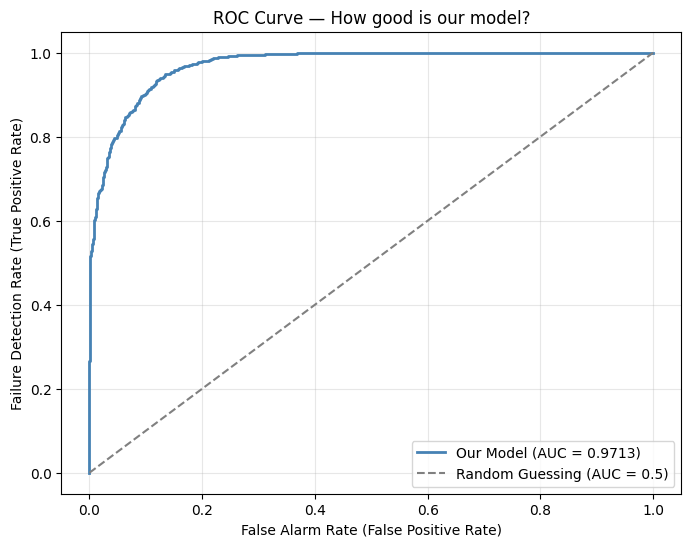

AUC-ROC: 0.9713

Reading this chart:
- The HIGHER the curve, the better the model
- A curve hugging the top-left corner = perfect model
- A straight diagonal line = useless random guessing
- Our model AUC of 0.9713 means:
  If you pick one failing engine and one healthy engine at random,
  our model correctly identifies which is which 97.1% of the time


In [32]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_val, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# Plot the model's ROC curve
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Our Model (AUC = {roc_auc:.4f})')

# Plot a diagonal line = random guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.5)')

# Formatting
plt.xlabel('False Alarm Rate (False Positive Rate)')
plt.ylabel('Failure Detection Rate (True Positive Rate)')
plt.title('ROC Curve — How good is our model?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print()
print("Reading this chart:")
print("- The HIGHER the curve, the better the model")
print("- A curve hugging the top-left corner = perfect model")
print("- A straight diagonal line = useless random guessing")
print(f"- Our model AUC of {roc_auc:.4f} means:")
print(f"  If you pick one failing engine and one healthy engine at random,")
print(f"  our model correctly identifies which is which {roc_auc*100:.1f}% of the time")

## 31. Save everything we'll need later

In [33]:
import pickle

# Save the scaler (we need this to normalize new data the same way)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the list of useful sensors (we need this to know which sensors to use)
with open('useful_sensors.pkl', 'wb') as f:
    pickle.dump(useful_sensors, f)

# Save final metrics to a text file
with open('model_results.txt', 'w') as f:
    f.write(f"Dataset: FD001\n")
    f.write(f"Model: CNN1D\n")
    f.write(f"AUC-ROC: {roc_auc:.4f}\n")
    f.write(f"Accuracy: {accuracy:.1f}%\n")
    f.write(f"Miss Rate: {miss_rate:.1f}%\n")
    f.write(f"False Alarm Rate: {false_alarm_rate:.1f}%\n")
    f.write(f"Useful sensors: {useful_sensors}\n")

print("Saved:")
print("  best_model.pt      ← the trained model weights")
print("  scaler.pkl         ← the normalization scaler")
print("  useful_sensors.pkl ← list of useful sensor names")
print("  model_results.txt  ← your final scores")

Saved:
  best_model.pt      ← the trained model weights
  scaler.pkl         ← the normalization scaler
  useful_sensors.pkl ← list of useful sensor names
  model_results.txt  ← your final scores
